In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('dseats_2024_training_dataset.csv')
df.head()

,PRODUCTION DATE,Field Name,WELL_BORE_CODE,N_WELL_BORE_CODE,WellBore Name,FLOW_KIND,WELL_TYPE,Downhole Pressure (PSI),Downhole Temperature (Kelvin),Average Tubing Pressure,Annulus Pressure (PSI),AVG WHP (PSI),Choke Size,Oil Production (stb/day),Gas Volume (scf/day),Water Production (stb/day)
0,04/07/2014,DSEAT,DSEAT-001-F-1 C,105,001-F-1 C,production,OP,0.00000,273.15000,0.00000,0.0,0.00000,0.00000,0.0,0.0,0.0
1,04/08/2014,DSEAT,DSEAT-001-F-1 C,105,001-F-1 C,production,OP,0.00000,273.15000,0.00000,0.0,0.00000,0.00000,0.0,0.0,0.0
2,04/09/2014,DSEAT,DSEAT-001-F-1 C,105,001-F-1 C,production,OP,0.00000,273.15000,0.00000,0.0,0.00000,0.00000,0.0,0.0,0.0
3,04/10/2014,DSEAT,DSEAT-001-F-1 C,105,001-F-1 C,production,OP,0.00000,273.15000,0.00000,0.0,0.00000,0.00000,0.0,0.0,0.0
4,04/11/2014,DSEAT,DSEAT-001-F-1 C,105,001-F-1 C,production,OP,4500.45403,370.02589,4020.53477,0.0,479.91926,33.07195,0.0,0.0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6925 entries, 0 to 6924
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PRODUCTION DATE                6925 non-null   object 
 1   Field Name                     6925 non-null   object 
 2   WELL_BORE_CODE                 6925 non-null   object 
 3   N_WELL_BORE_CODE               6925 non-null   int64  
 4   WellBore Name                  6925 non-null   object 
 5   FLOW_KIND                      6925 non-null   object 
 6   WELL_TYPE                      6925 non-null   object 
 7   Downhole Pressure (PSI)        6925 non-null   float64
 8   Downhole Temperature (Kelvin)  6925 non-null   float64
 9   Average Tubing Pressure        6925 non-null   float64
 10  Annulus Pressure (PSI)         6925 non-null   float64
 11  AVG WHP (PSI)                  6925 non-null   float64
 12  Choke Size                     6919 non-null   f

In [4]:
df['PRODUCTION DATE'] = pd.to_datetime(df['PRODUCTION DATE'], format='mixed').dt.date
df['PRODUCTION DATE'] =df['PRODUCTION DATE'].astype('datetime64[ns]')

In [5]:
df['PRODUCTION DATE']

0      2014-04-07
1      2014-04-08
2      2014-04-09
3      2014-04-10
4      2014-04-11
          ...    
6920   2015-06-26
6921   2015-06-27
6922   2015-06-28
6923   2015-06-29
6924   2015-06-30
Name: PRODUCTION DATE, Length: 6925, dtype: datetime64[ns]

In [6]:
#
#df['PRODUCTION DATE'] = df['PRODUCTION DATE'].dt.strftime('%Y-%m-%d')
#df['PRODUCTION DATE'] = pd.to_datetime(df['PRODUCTION DATE'], format='%Y-%m-%d')

In [7]:
df.dtypes

PRODUCTION DATE                  datetime64[ns]
Field Name                               object
WELL_BORE_CODE                           object
N_WELL_BORE_CODE                          int64
WellBore Name                            object
FLOW_KIND                                object
WELL_TYPE                                object
Downhole Pressure (PSI)                 float64
Downhole Temperature (Kelvin)           float64
Average Tubing Pressure                 float64
Annulus Pressure (PSI)                  float64
AVG WHP (PSI)                           float64
Choke Size                              float64
Oil Production (stb/day)                float64
Gas Volume (scf/day)                    float64
Water Production (stb/day)              float64
dtype: object

In [8]:
df.head()

,PRODUCTION DATE,Field Name,WELL_BORE_CODE,N_WELL_BORE_CODE,WellBore Name,FLOW_KIND,WELL_TYPE,Downhole Pressure (PSI),Downhole Temperature (Kelvin),Average Tubing Pressure,Annulus Pressure (PSI),AVG WHP (PSI),Choke Size,Oil Production (stb/day),Gas Volume (scf/day),Water Production (stb/day)
0,2014-04-07,DSEAT,DSEAT-001-F-1 C,105,001-F-1 C,production,OP,0.00000,273.15000,0.00000,0.0,0.00000,0.00000,0.0,0.0,0.0
1,2014-04-08,DSEAT,DSEAT-001-F-1 C,105,001-F-1 C,production,OP,0.00000,273.15000,0.00000,0.0,0.00000,0.00000,0.0,0.0,0.0
2,2014-04-09,DSEAT,DSEAT-001-F-1 C,105,001-F-1 C,production,OP,0.00000,273.15000,0.00000,0.0,0.00000,0.00000,0.0,0.0,0.0
3,2014-04-10,DSEAT,DSEAT-001-F-1 C,105,001-F-1 C,production,OP,0.00000,273.15000,0.00000,0.0,0.00000,0.00000,0.0,0.0,0.0
4,2014-04-11,DSEAT,DSEAT-001-F-1 C,105,001-F-1 C,production,OP,4500.45403,370.02589,4020.53477,0.0,479.91926,33.07195,0.0,0.0,0.0


In [9]:
df.shape

(6925, 16)

In [10]:
df.isna().sum()

PRODUCTION DATE                  0
Field Name                       0
WELL_BORE_CODE                   0
N_WELL_BORE_CODE                 0
WellBore Name                    0
FLOW_KIND                        0
WELL_TYPE                        0
Downhole Pressure (PSI)          0
Downhole Temperature (Kelvin)    0
Average Tubing Pressure          0
Annulus Pressure (PSI)           0
AVG WHP (PSI)                    0
Choke Size                       6
Oil Production (stb/day)         0
Gas Volume (scf/day)             0
Water Production (stb/day)       0
dtype: int64

In [11]:
# Copy dataframe to avoid modifying the original
df1 = df.copy()

Text(0.5, 1.0, 'Oil Production Over Time')

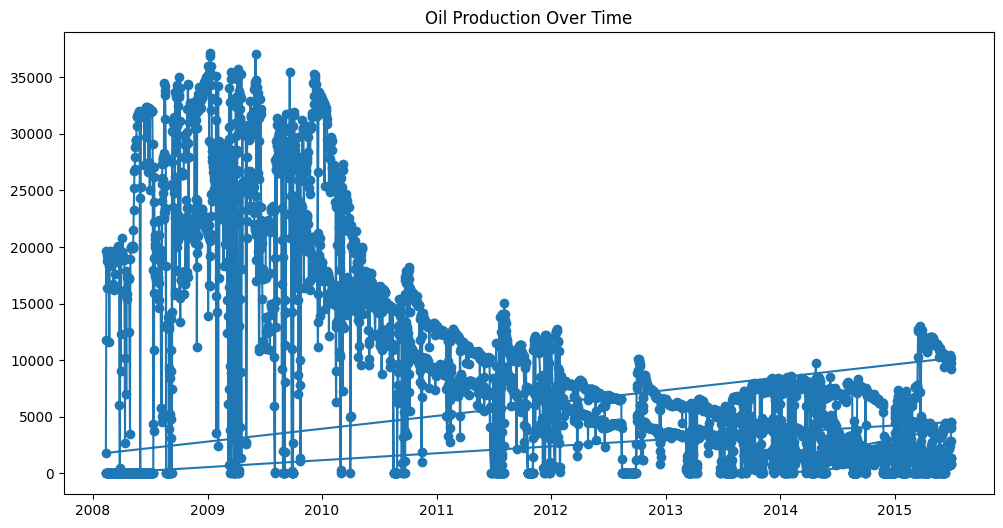

In [12]:
# plot the time series
plt.figure(figsize=(12, 6))
plt.plot(df1['PRODUCTION DATE'], df1['Oil Production (stb/day)'], marker='o', linestyle='-')
plt.title('Oil Production Over Time')

## Feature Engineering

In [13]:
# split the date column into year, month, day
df["year"] = df["PRODUCTION DATE"].dt.year
df["month"] = df["PRODUCTION DATE"].dt.month
df["day"] = df["PRODUCTION DATE"].dt.day

In [14]:
df.head(1)

,PRODUCTION DATE,Field Name,WELL_BORE_CODE,N_WELL_BORE_CODE,WellBore Name,FLOW_KIND,WELL_TYPE,Downhole Pressure (PSI),Downhole Temperature (Kelvin),Average Tubing Pressure,Annulus Pressure (PSI),AVG WHP (PSI),Choke Size,Oil Production (stb/day),Gas Volume (scf/day),Water Production (stb/day),year,month,day
0,2014-04-07,DSEAT,DSEAT-001-F-1 C,105,001-F-1 C,production,OP,0.0,273.15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2014,4,7


In [15]:
# drop the original date column
df.drop(columns=['PRODUCTION DATE'], axis=1, inplace=True)

In [16]:
df.drop(columns=['Field Name'], axis=1, inplace=True)

In [17]:
# 
cat_col = df.select_dtypes(include='object').columns
num_col = df.select_dtypes(include='number').columns
print("Categorical columns:", cat_col)
print("Numerical columns:", num_col)

Categorical columns: Index(['WELL_BORE_CODE', 'WellBore Name', 'FLOW_KIND', 'WELL_TYPE'], dtype='object')
Numerical columns: Index(['N_WELL_BORE_CODE', 'Downhole Pressure (PSI)',
       'Downhole Temperature (Kelvin)', 'Average Tubing Pressure',
       'Annulus Pressure (PSI)', 'AVG WHP (PSI)', 'Choke Size',
       'Oil Production (stb/day)', 'Gas Volume (scf/day)',
       'Water Production (stb/day)', 'year', 'month', 'day'],
      dtype='object')


In [18]:
## remove outliers using inter-quartile range approach
def remove_outliers(df):
    for col in df.columns:
        if df[col].dtypes !='object':
            q1,q3 = df[col].quantile([0.25,0.75])
            iqr = q3-q1
            lower = q1-1.5*iqr
            upper = q3+1.5*iqr
            df[col] = np.where(df[col]<lower,lower,df[col])
            df[col] = np.where(df[col]>upper,upper,df[col])
    return df

In [19]:
df2 = remove_outliers(df)

In [20]:
# split the data into features and target
X = df2.drop(columns=['Oil Production (stb/day)', 'Gas Volume (scf/day)','Water Production (stb/day)'], axis=1)
Y = df2[['Oil Production (stb/day)', 'Gas Volume (scf/day)','Water Production (stb/day)']]

In [21]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=402)

### Creating Pipeline for Transformation

In [22]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [23]:
numeric_features = ['Downhole Pressure (PSI)',
       'Downhole Temperature (Kelvin)', 'Average Tubing Pressure',
       'Annulus Pressure (PSI)', 'AVG WHP (PSI)', 'Choke Size',
       'year', 'month', 'day'
       ]
categorical_features = ['WELL_TYPE']
#'WELL_BORE_CODE', 'WellBore Name','N_WELL_BORE_CODE'

In [24]:
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler(feature_range=(0,1)))
    ]
)

categorical_transformer =OneHotEncoder(handle_unknown='ignore')


In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

#### Preprocess the train data

In [26]:
import pickle
# preprocess the train data
x_train_preprocessed = preprocessor.fit_transform(x_train)
x_test_preprocessed = preprocessor.transform(x_test)

#pickle.dump(preprocessor, open('preprocessor.pkl', 'wb'))
y_scaler = MinMaxScaler(feature_range=(0,1))
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

### Training the Models

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,HistGradientBoostingRegressor,ExtraTreesRegressor,GradientBoostingRegressor,BaggingRegressor,AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.multioutput import MultiOutputRegressor

In [29]:
# training function
def train_model(model, x_train, y_train, x_test, y_test):
    model.fit(x_train, y_train)
    # model testing
    y_pred = model.predict(x_test)


    # Model Evaluation
    print("Model Evaluation")
    print('='*45)
    print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))
    print("Mean Squared Error: ",mean_squared_error(y_test,y_pred))
    print("Root Mean Squared Error: ",np.sqrt(mean_squared_error(y_test,y_pred)))
    r2score =r2_score(y_test,y_pred)
    print("R2 Score: ",r2score)
    return model


In [30]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': MultiOutputRegressor(RandomForestRegressor(n_estimators=500, criterion='friedman_mse',max_features='sqrt')),
    'XGBoost': XGBRegressor(),
    'HistGradientBoosting': MultiOutputRegressor(HistGradientBoostingRegressor()),
    'Extra Trees': ExtraTreesRegressor(n_estimators=500, max_depth=50, random_state=42),
    'Support Vector Regressor': MultiOutputRegressor(SVR()),
    'Decision Tree': DecisionTreeRegressor(),
    'K-Neighbors Regressor': MultiOutputRegressor(KNeighborsRegressor()),
    'Gradient Boosting': MultiOutputRegressor(GradientBoostingRegressor()),
    'Bagging Regressor': MultiOutputRegressor(BaggingRegressor()),
    'AdaBoost Regressor': MultiOutputRegressor(AdaBoostRegressor())
    
}
for name, model in models.items():
    print(f'Training {name}...')
    trained_model = train_model(model, x_train_preprocessed, y_train_scaled, x_test_preprocessed, y_test_scaled)
    print('\n')

Training Linear Regression...
Model Evaluation
Mean Absolute Error: 0.10140423295767098
Mean Squared Error:  0.019831118006458964
Root Mean Squared Error:  0.14082300240535622
R2 Score:  0.7392690668807645


Training Random Forest...


MemoryError: could not allocate 524288 bytes

In [ ]:
from lightgbm import LGBMRegressor

# Train LightGBM for multioutput regression
lgbm = MultiOutputRegressor(LGBMRegressor())
model_lgbm = train_model(lgbm, x_train_preprocessed, y_train_scaled, x_test_preprocessed, y_test_scaled)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000783 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1581
[LightGBM] [Info] Number of data points in the train set: 4847, number of used features: 9
[LightGBM] [Info] Start training from score 0.305253
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000269 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1581
[LightGBM] [Info] Number of data points in the train set: 4847, number of used features: 9
[LightGBM] [Info] Start training from score 0.301170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000274 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1581
[LightGBM] [Info] Number of data points in the train set: 4847, number of used features: 9
[LightGBM] [Info] Start training 

In [30]:
extr = ExtraTreesRegressor(n_estimators=500, max_depth=50, random_state=42)
extr.fit(x_train_preprocessed, y_train_scaled)
y_pred_extr = extr.predict(x_test_preprocessed)
pickle.dump(extr, open('extr_model.pkl', 'wb'))

In [28]:
rf = RandomForestRegressor(n_estimators=500, criterion='friedman_mse', max_features='sqrt')
rf.fit(x_train_preprocessed, y_train_scaled)
y_pred_rf = rf.predict(x_test_preprocessed)
pickle.dump(rf, open('rf_model.pkl', 'wb'))


In [29]:
xgb= XGBRegressor(n_estimators=500, max_depth=10, learning_rate=0.1, random_state=42)
xgb.fit(x_train_preprocessed, y_train_scaled)
y_pred_xgb = xgb.predict(x_test_preprocessed)
pickle.dump(xgb, open('xgb_model.pkl', 'wb'))

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Regression plot function
def plot_actual_vs_predicted(y_true, y_pred, labels=["Oil", "Gas", "Water"]):
    n_outputs = y_true.shape[1]
    fig, axes = plt.subplots(1, n_outputs, figsize=(6 * n_outputs, 5))

    for i in range(n_outputs):
        ax = axes[i] if n_outputs > 1 else axes
        sns.regplot(x=y_true[:, i], y=y_pred[:, i], ax=ax,
                    scatter_kws={"s": 30}, line_kws={"color": "red"})
        ax.set_xlabel(f"Actual {labels[i]}")
        ax.set_ylabel(f"Predicted {labels[i]}")
        ax.set_title(f"{labels[i]}: Actual vs Predicted")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

# Training function
def train_model(model, x_train, y_train, x_test, y_test, labels=["Oil", "Gas", "Water"]):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print("=" * 55)
    print(f"Model Evaluation")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"Root Mean Squared Error: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")

    # Plot
    plot_actual_vs_predicted(np.array(y_scaler.inverse_transform(y_test)), np.array(y_scaler.inverse_transform(y_pred)), labels)

    return model



🔧 Training: Linear Regression
Model Evaluation
Mean Absolute Error: 0.0999
Root Mean Squared Error: 0.1393
R2 Score: 0.7438


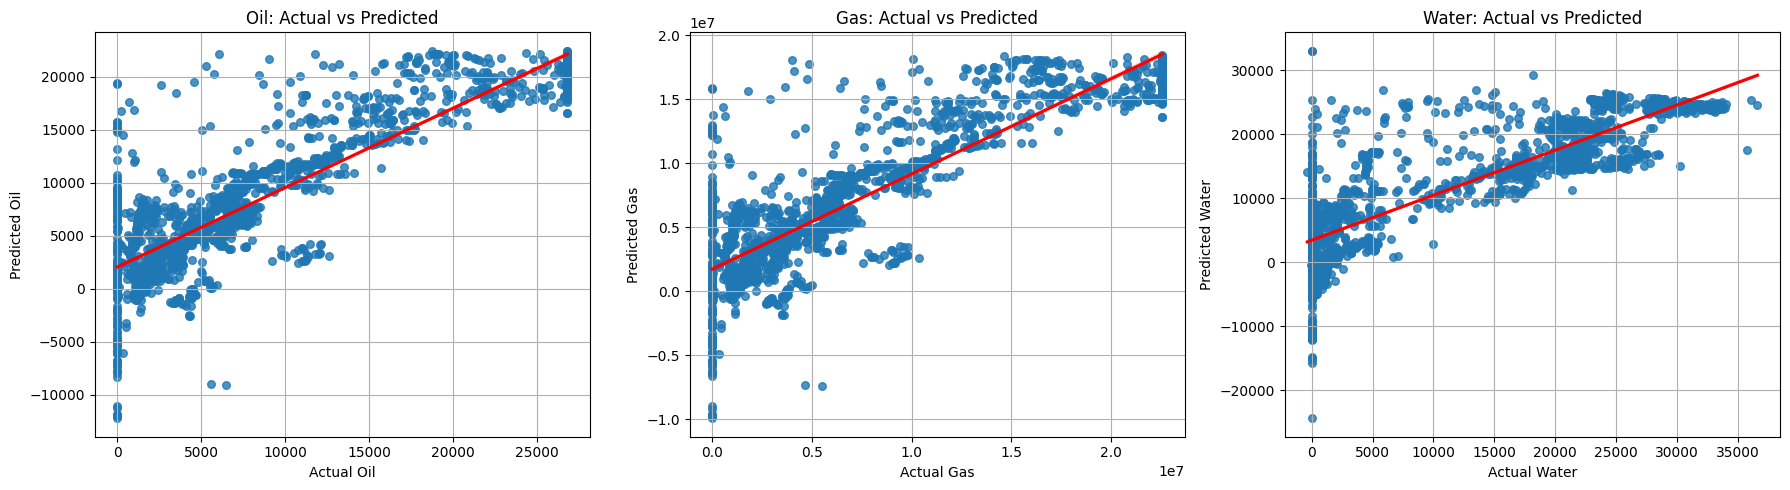


🔧 Training: Random Forest
Model Evaluation
Mean Absolute Error: 0.0214
Root Mean Squared Error: 0.0551
R2 Score: 0.9594


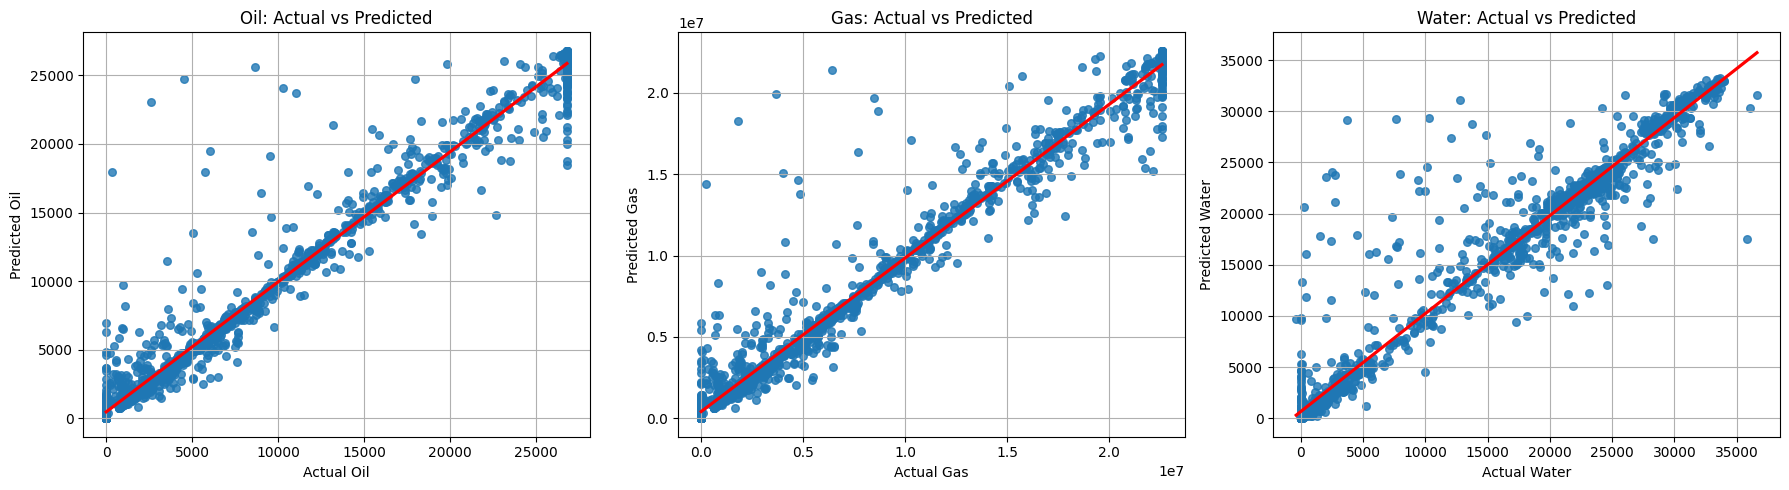


🔧 Training: XGBoost
Model Evaluation
Mean Absolute Error: 0.0249
Root Mean Squared Error: 0.0615
R2 Score: 0.9500


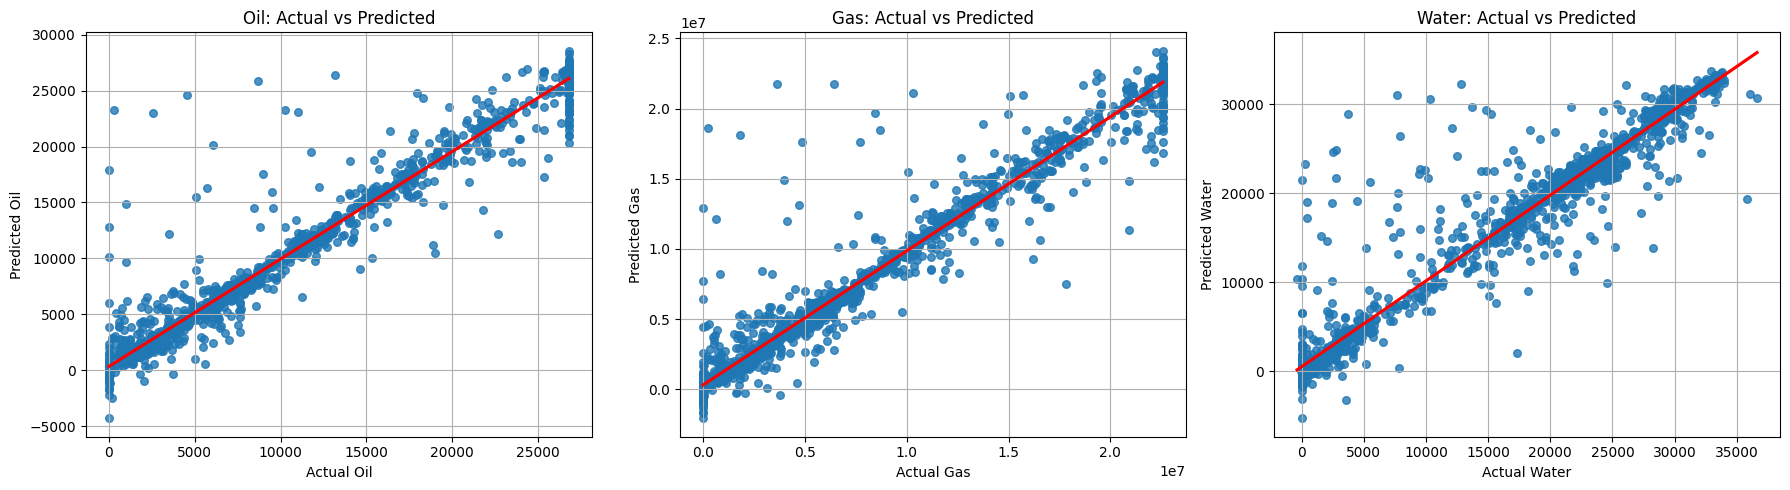


🔧 Training: HistGradientBoosting
Model Evaluation
Mean Absolute Error: 0.0254
Root Mean Squared Error: 0.0591
R2 Score: 0.9529


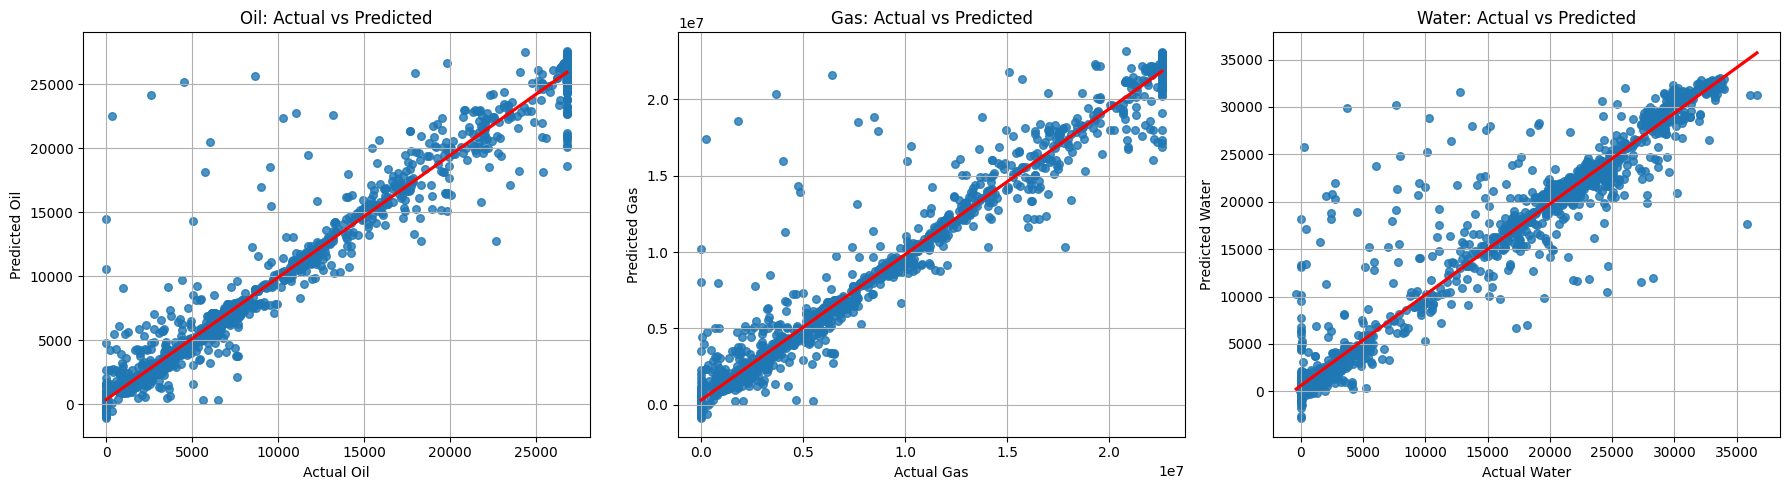


🔧 Training: Extra Trees
Model Evaluation
Mean Absolute Error: 0.0180
Root Mean Squared Error: 0.0540
R2 Score: 0.9614


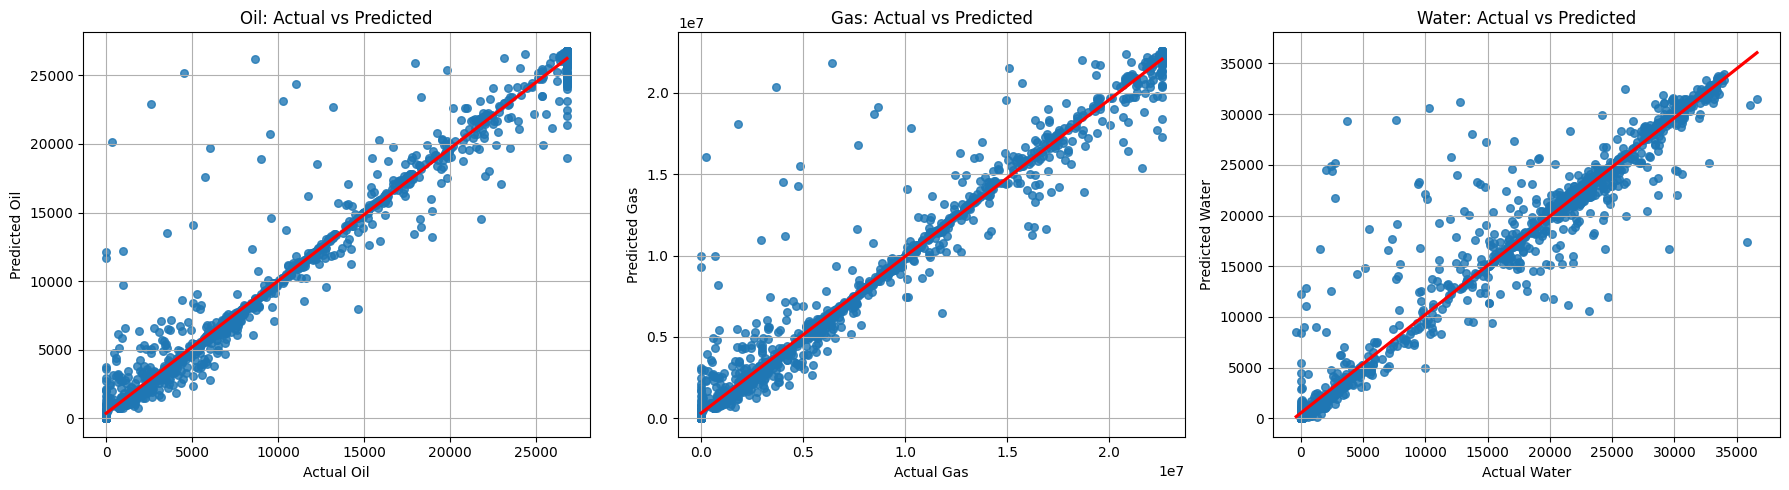


🔧 Training: Support Vector Regressor
Model Evaluation
Mean Absolute Error: 0.0679
Root Mean Squared Error: 0.0919
R2 Score: 0.8880


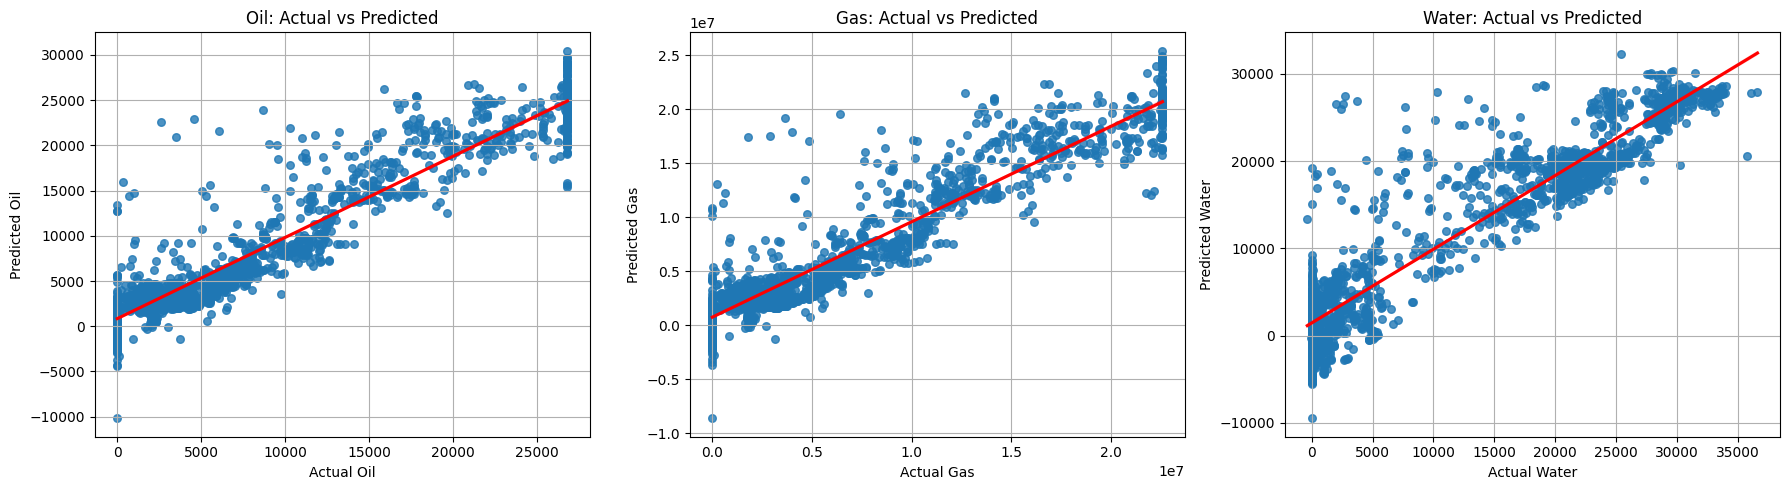


🔧 Training: Decision Tree
Model Evaluation
Mean Absolute Error: 0.0248
Root Mean Squared Error: 0.0766
R2 Score: 0.9212


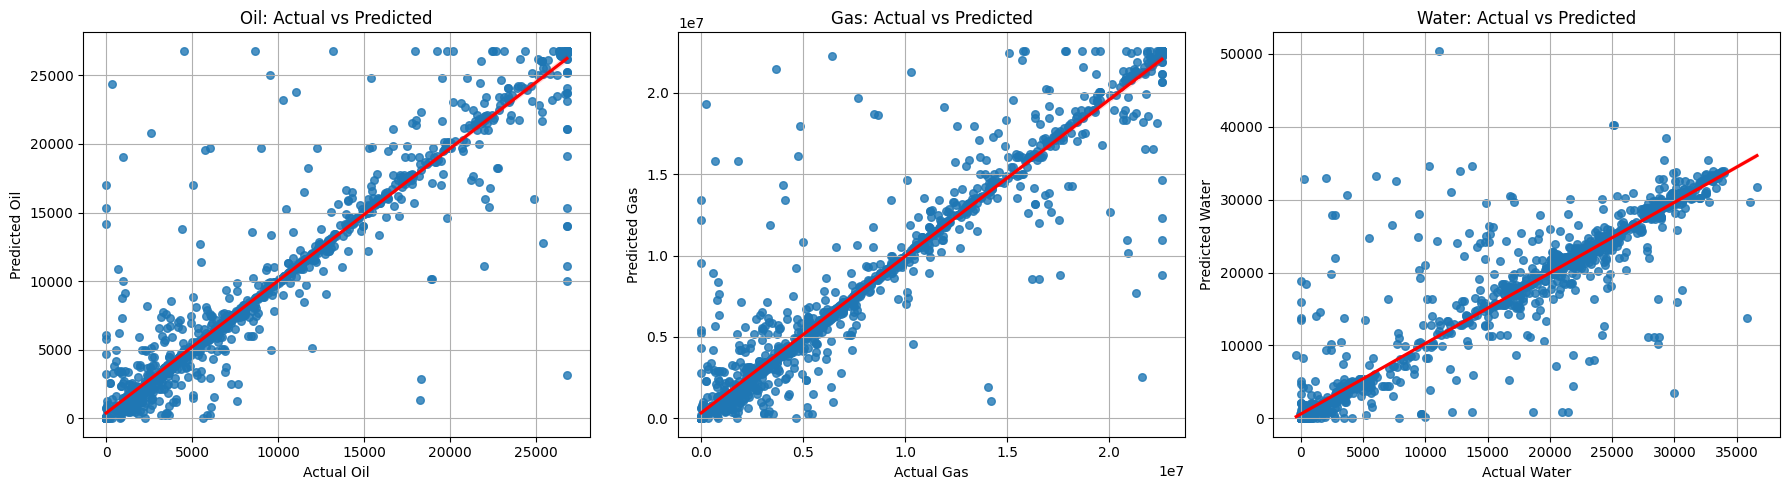


🔧 Training: K-Neighbors Regressor
Model Evaluation
Mean Absolute Error: 0.0276
Root Mean Squared Error: 0.0719
R2 Score: 0.9323


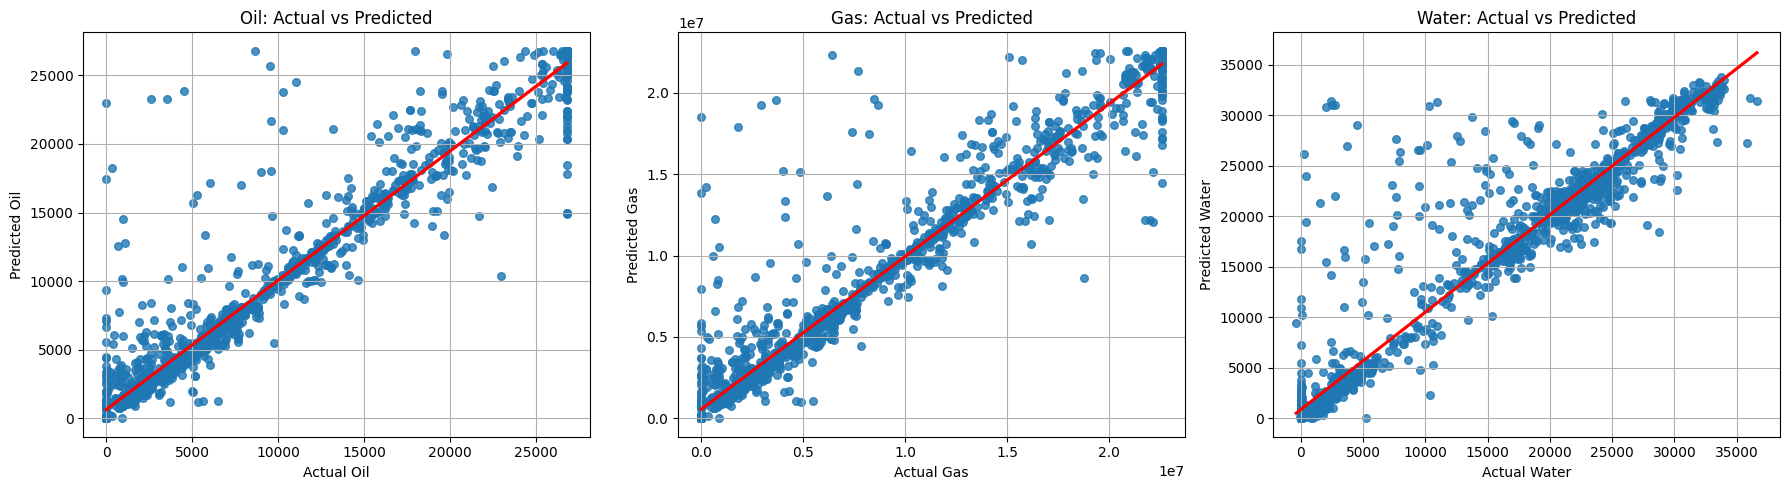


🔧 Training: Gradient Boosting
Model Evaluation
Mean Absolute Error: 0.0410
Root Mean Squared Error: 0.0724
R2 Score: 0.9316


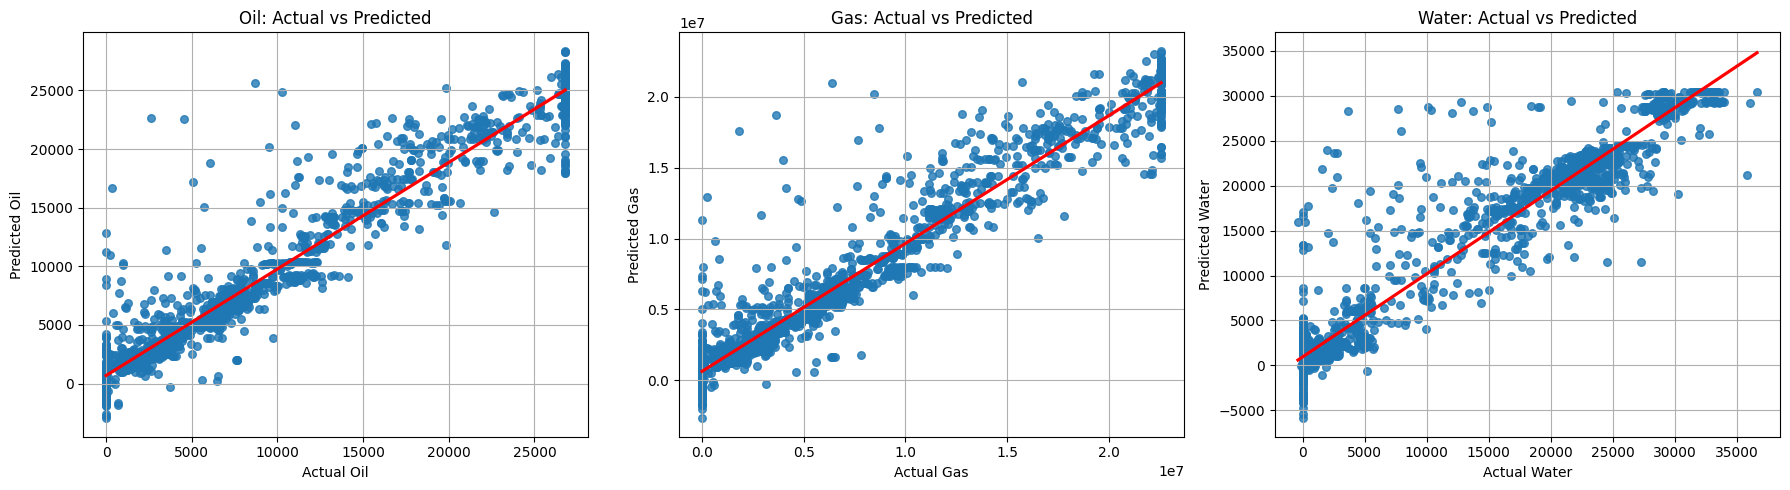


🔧 Training: Bagging Regressor
Model Evaluation
Mean Absolute Error: 0.0228
Root Mean Squared Error: 0.0623
R2 Score: 0.9478


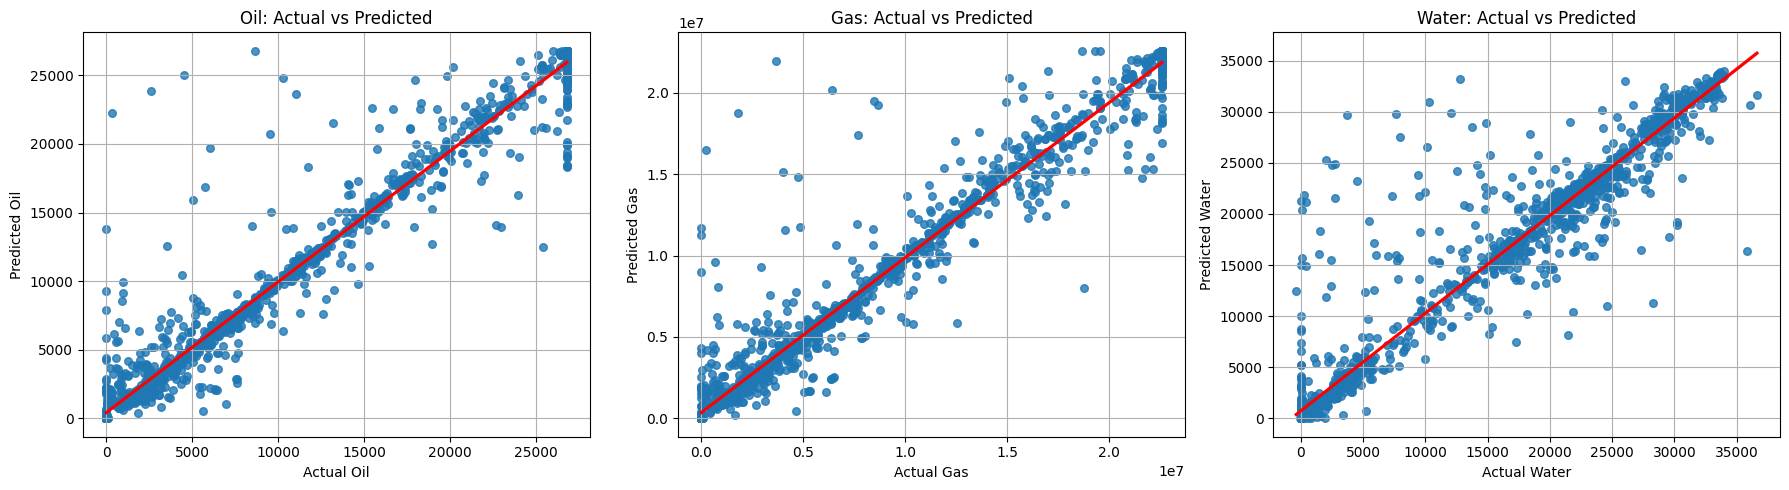


🔧 Training: AdaBoost Regressor
Model Evaluation
Mean Absolute Error: 0.1018
Root Mean Squared Error: 0.1328
R2 Score: 0.7656


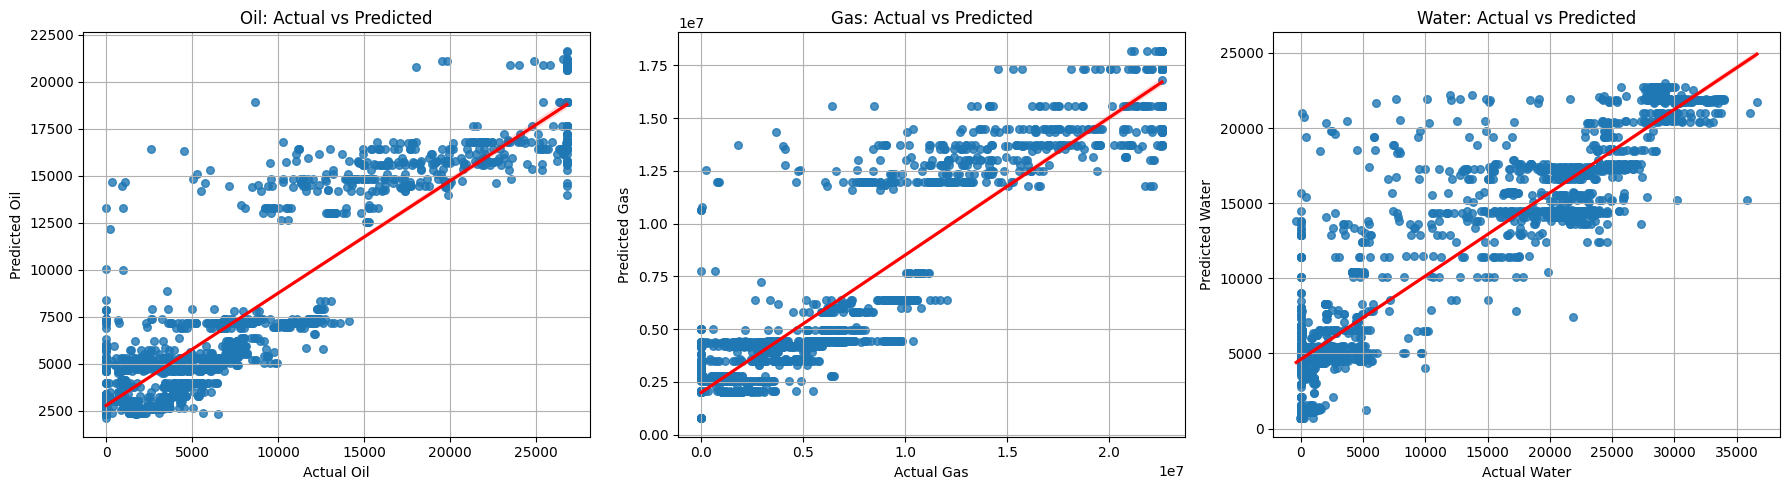

In [42]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': MultiOutputRegressor(RandomForestRegressor(n_estimators=500, criterion='friedman_mse', max_features='sqrt')),
    'XGBoost': XGBRegressor(),
    'HistGradientBoosting': MultiOutputRegressor(HistGradientBoostingRegressor()),
    'Extra Trees': ExtraTreesRegressor(n_estimators=500, max_depth=50, random_state=42),
    'Support Vector Regressor': MultiOutputRegressor(SVR()),
    'Decision Tree': DecisionTreeRegressor(),
    'K-Neighbors Regressor': MultiOutputRegressor(KNeighborsRegressor()),
    'Gradient Boosting': MultiOutputRegressor(GradientBoostingRegressor()),
    'Bagging Regressor': MultiOutputRegressor(BaggingRegressor()),
    'AdaBoost Regressor': MultiOutputRegressor(AdaBoostRegressor())
}

for name, model in models.items():
    print(f"\n🔧 Training: {name}")
    trained_model = train_model(
        model,
        x_train_preprocessed,
        y_train_scaled,
        x_test_preprocessed,
        y_test_scaled,
        labels=["Oil", "Gas", "Water"]
    )


In [44]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import streamlit as st

# Function to generate SHAP plots for any model type
def explain_model_with_shap(model, x_train, x_sample, feature_names=None, use_streamlit=True):
    """
    model: Trained model (regressor)
    x_train: Full training feature set (numpy or DataFrame)
    x_sample: A small sample (e.g., 50 rows) for SHAP summary plot
    feature_names: List of feature names (if not using DataFrame)
    use_streamlit: Set to False to use in notebooks
    """

    st.subheader("🔍 SHAP Feature Importance")

    try:
        # Choose the appropriate SHAP explainer
        if hasattr(model, "estimators_") or hasattr(model, "feature_importances_"):
            # Tree-based models (e.g., RandomForest, XGBoost, etc.)
            explainer = shap.Explainer(model, x_train)
            shap_values = explainer(x_sample)
        else:
            # Fallback to KernelExplainer for non-tree models (e.g., LinearRegression)
            explainer = shap.KernelExplainer(model.predict, x_train)
            shap_values = explainer.shap_values(x_sample)

        # Plot SHAP summary
        if use_streamlit:
            fig, ax = plt.subplots(figsize=(10, 5))
            shap.summary_plot(shap_values, x_sample, feature_names=feature_names, show=False)
            st.pyplot(fig)
        else:
            shap.summary_plot(shap_values, x_sample, feature_names=feature_names)
        
    except Exception as e:
        if use_streamlit:
            st.warning(f"⚠️ SHAP explanation failed: {e}")
        else:
            print(f"SHAP explanation failed: {e}")


Model Evaluation
Mean Absolute Error: 0.0214
Root Mean Squared Error: 0.0543
R2 Score: 0.9608


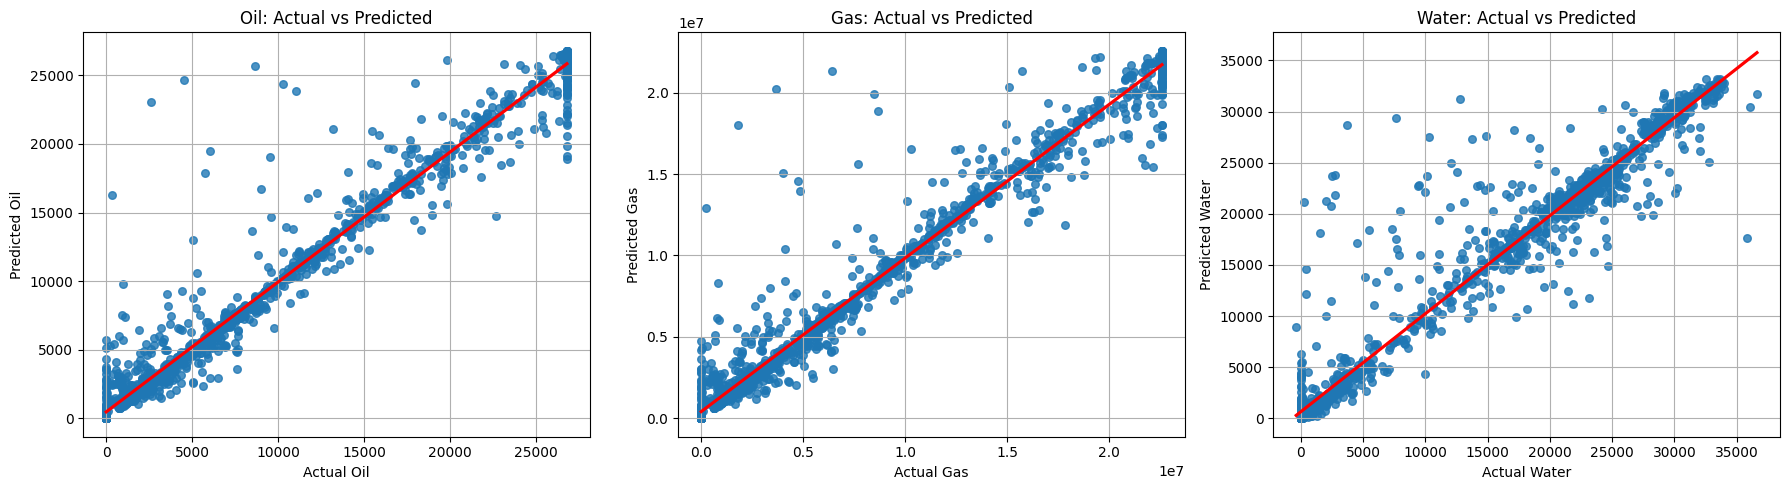

In [67]:
rfr =RandomForestRegressor(n_estimators=500, criterion='friedman_mse',max_features='sqrt')
model_rfr = train_model(rfr, x_train_preprocessed, y_train_scaled,x_test_preprocessed, y_test_scaled)

Model Evaluation
Mean Absolute Error: 0.0230
Root Mean Squared Error: 0.0603
R2 Score: 0.9520


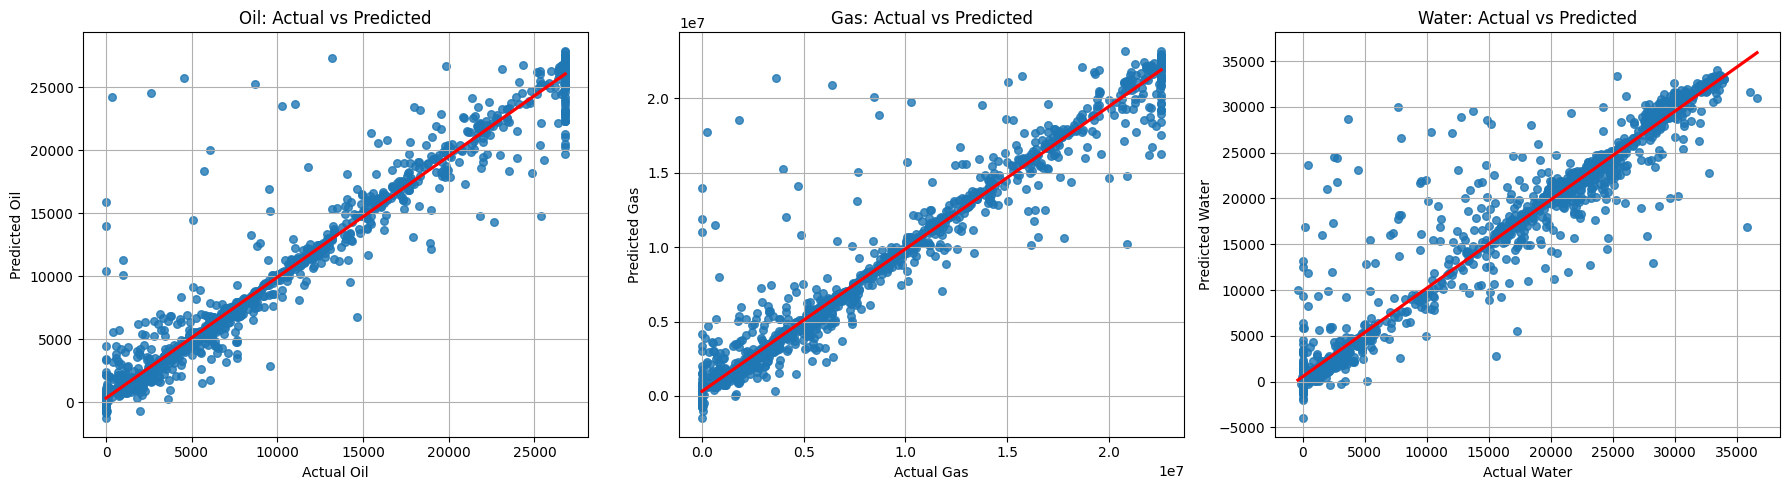

In [68]:
xgb= XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=7, random_state=None)
model_xgb = train_model(xgb, x_train_preprocessed, y_train_scaled,x_test_preprocessed, y_test_scaled)

In [ ]:
hgr= MultiOutputRegressor(estimator=ExtraTreesRegressor(n_estimators=500, max_depth=50, random_state=42))
model_hgr = train_model(hgr, x_train_preprocessed, y_train_scaled,x_test_preprocessed, y_test_scaled)

Model Evaluation
Mean Absolute Error: 0.018129804935991978
Mean Squared Error:  0.002873518832881278
Root Mean Squared Error:  0.05360521273981923
R2 Score:  0.9617759324937453


In [48]:
hgr= MultiOutputRegressor(estimator=RandomForestRegressor(),n_jobs=50)
model_hgr = train_model(hgr, x_train_preprocessed, y_train_scaled,x_test_preprocessed, y_test_scaled)

Model Evaluation
Mean Absolute Error: 0.02164204696228177
Mean Squared Error:  0.0035900019075566243
Root Mean Squared Error:  0.05991662463420836
R2 Score:  0.952330280047187


In [ ]:
from interpret.glassbox import ExplainableBoostingRegressor

# Train EBMs for multioutput regression
ebm = MultiOutputRegressor(ExplainableBoostingRegressor(learning_rate=0.01))
model_ebm = train_model(ebm, x_train_preprocessed, y_train_scaled, x_test_preprocessed, y_test_scaled)

### Hyperparameter Tuning

In [52]:
# parameters for random forestRegressor
params_rfr = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 7, 9, 11],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['absolute_error', 'squared_error', 'friedman_mse'],
}



params ={
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 7, 9, 11],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [0, 0.1, 0.5, 1],
}

In [66]:
r_search_rfr = RandomizedSearchCV(estimator=RandomForestRegressor(), param_distributions=params_rfr, cv=5,n_iter=50, n_jobs=-1, verbose=1)
r_search_rfr.fit(x_train_preprocessed, y_train_scaled)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=50,
                   n_jobs=-1,
                   param_distributions={'criterion': ['absolute_error',
                                                      'squared_error',
                                                      'friedman_mse'],
                                        'max_depth': [3, 5, 7, 9, 11],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500]},
                   verbose=1)

In [63]:
r_search_rfr.best_score_

np.float64(0.9434517378765696)

In [67]:
xgb_search_rfr = RandomizedSearchCV(estimator=XGBRegressor(), param_distributions=params, cv=5,n_iter=50, n_jobs=-1, verbose=1)
xgb_search_rfr.fit(x_train_preprocessed, y_train_scaled)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=...
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None,
                                          random_state=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 5, 7, 9, 11],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'reg_alpha': [0, 0.1, 0.5, 1],
                                        'reg_lambda': [0, 0.1, 0.5, 1],
                                        'subsample': [0.6, 0.8, 1.0]},
                   verbose=1)

In [68]:
xgb_search_rfr.best_score_

np.float64(0.9519030530998481)

In [79]:
import shap
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.multioutput import MultiOutputRegressor

# Helper to extract feature names after ColumnTransformer
def get_feature_names(preprocessor, numeric_features, categorical_features):
    feature_names = []

    for name, transformer, cols in preprocessor.transformers:
        if name == 'num':
            feature_names.extend(numeric_features)

        elif name == 'cat':
            if hasattr(transformer, 'categories_'):
                for i, cats in enumerate(transformer.categories_):
                    col_name = categorical_features[i]
                    feature_names.extend([f"{col_name}_{cat}" for cat in cats])
            else:
                feature_names.extend(categorical_features)

    return feature_names


def plot_and_display_shap_kernel_summary(
    model,
    preprocessor,
    x_train,
    output_names=["Target"],
    sample_size=100,
    save_dir="shap_kernel_summary_plots"
):
    """
    Generate and display SHAP Kernel summary plots (and save to file) for a given model and data.

    Parameters:
    - model: trained model (can be wrapped in MultiOutputRegressor)
    - preprocessor: fitted sklearn ColumnTransformer
    - x_train: original (untransformed) training DataFrame
    - output_names: list of output labels
    - sample_size: number of samples to explain
    - save_dir: folder to save PNG plots
    """
    os.makedirs(save_dir, exist_ok=True)

    # Sample and transform
    sample = x_train.sample(n=min(sample_size, len(x_train)), random_state=42)
    sample_transformed = preprocessor.transform(sample)

    # Automatically get feature names
    feature_names = preprocessor.get_feature_names_out()
    sample_df = pd.DataFrame(sample_transformed, columns=feature_names)

    # Determine if model is multi-output
    if isinstance(model, MultiOutputRegressor):
        for i, est in enumerate(model.estimators_):
            output_name = output_names[i] if i < len(output_names) else f"Target {i+1}"
            explainer = shap.KernelExplainer(est.predict, sample_df)
            shap_values = explainer.shap_values(sample_df, nsamples="auto")

            plt.figure()
            shap.summary_plot(shap_values, sample_df, show=True)
            plt.savefig(f"{save_dir}/shap_kernel_summary_{output_name.replace(' ', '_')}.png", bbox_inches='tight', dpi=300)
    else:
        explainer = shap.KernelExplainer(model.predict, sample_df)
        shap_values = explainer.shap_values(sample_df, nsamples="auto")

        plt.figure()
        shap.summary_plot(shap_values, sample_df, show=True)
        plt.savefig(f"{save_dir}/shap_kernel_summary_single_output.png", bbox_inches='tight', dpi=300)



  0%|          | 0/100 [00:00<?, ?it/s]

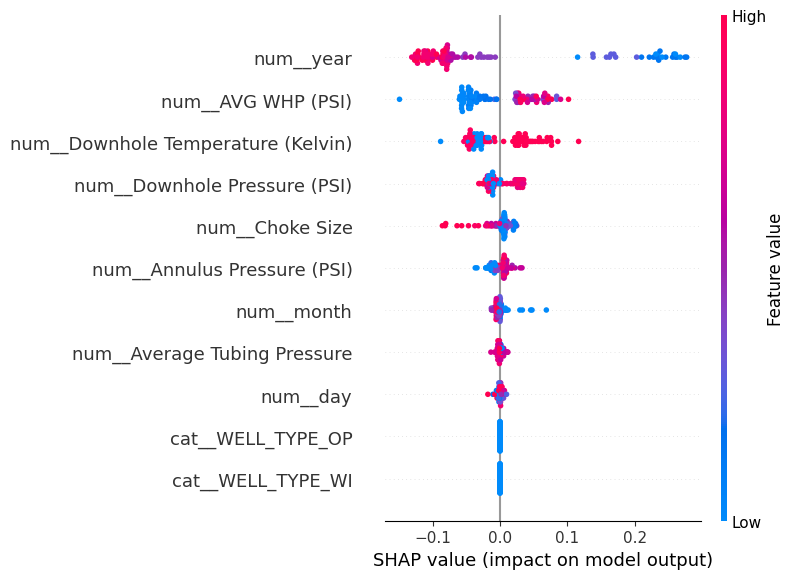

  0%|          | 0/100 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

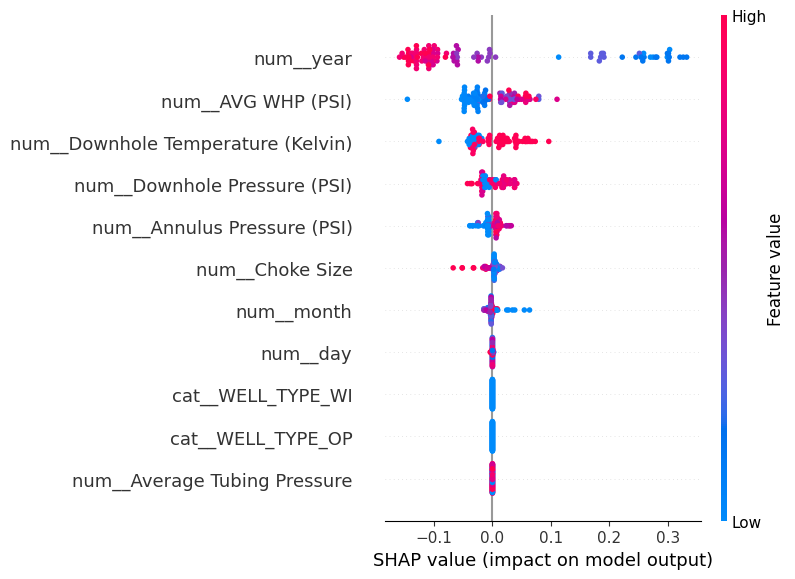

  0%|          | 0/100 [00:00<?, ?it/s]

<Figure size 640x480 with 0 Axes>

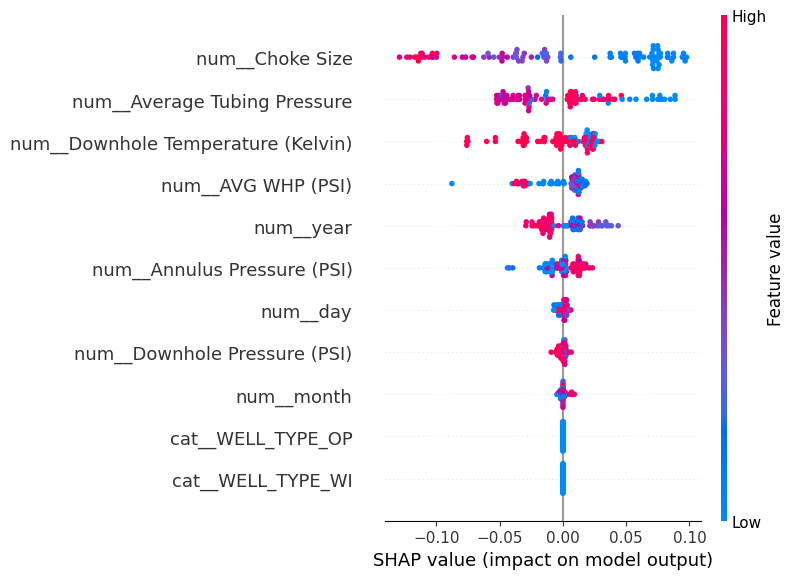

<Figure size 640x480 with 0 Axes>

In [80]:
plot_and_display_shap_kernel_summary(
    model=trained_model,
    preprocessor=preprocessor,
    x_train=x_train,
    output_names=["Oil Production", "Gas Volume", "Water Production"]
)


In [ ]:
import streamlit as st
import pandas as pd
import altair as alt
import streamlit_echarts as ste
import matplotlib as plt
import pickle
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

import plotly.express as px

st.set_page_config(
    page_title="Prediction of Oil, Gas, and Water Production rate using ML",
    page_icon=":graph:",
    layout="wide",
    initial_sidebar_state="expanded"
)
alt.themes.enable("dark")

def load_data():
    with st.sidebar:
        st.title("Oil, Gas, and Water Production Dashboard")    
        uploaded_file = st.sidebar.file_uploader("📂 Upload a CSV File", type=["csv"])
        if uploaded_file:
            val_data = pd.read_csv(uploaded_file)
            if not {"Year", "Oil Production (stb/day)", "Gas Production (mscf/day)", "Water Production (bbl/day)"}.issubset(val_data.columns):
                st.sidebar.error("Invalid CSV format. Ensure it contains 'Year', 'Oil Production', 'Gas Production', and 'Water Production' columns.")
        else:
            val_data = pd.DataFrame()  # fallback if no file uploaded

        if not val_data.empty:
            val_data['WELL_TYPE'] = val_data['WELL_TYPE'].astype('category').cat.codes
            val_data['PRODUCTION DATE'] = pd.to_datetime(val_data['PRODUCTION DATE'], format='mixed')
            val_data['year'] = val_data['PRODUCTION DATE'].dt.year
            val_data['month'] = val_data['PRODUCTION DATE'].dt.month
            val_data['day'] = val_data['PRODUCTION DATE'].dt.day

            input_features = val_data.drop(['Oil Production (stb/day)', 'Gas Volume (scf/day)',
                                            'Water Production (stb/day)', 'FLOW_KIND', 'WellBore Name',
                                            'WELL_BORE_CODE', 'Field Name', 'PRODUCTION DATE'], axis=1)
            st.title("🎛 Dashboard Filters")
            selected_year = st.selectbox("📅 Select a Year", sorted(val_data["Year"].unique(), reverse=True))
            selected_model = st.selectbox("🧠 Select Model", ["Linear Regression", "Decision Tree", "Random Forest"])
            return val_data, input_features
        else:
            return None, None

rfr = pickle.load(open('rfr_model.pkl', 'rb'))
x_scaler = pickle.load(open('x_scaler.pkl', 'rb'))
y_scaler = pickle.load(open('y_scaler.pkl', 'rb'))

def transform_data(input_features):
    input_features_scaled = x_scaler.transform(input_features)
    model = rfr
    predicted_values = model.predict(input_features_scaled)
    production_forecast = y_scaler.inverse_transform(predicted_values)
    oil_gas_water_prod = pd.DataFrame(production_forecast, columns=[
        'Predicted Oil Production (stb/day)', 'Predicted Gas Volume (scf/day)', 'Predicted Water Production (stb/day)'
    ])
    vald = pd.read_csv('dseats_2024_validation_dataset.csv')
    vald = vald.iloc[:, :-3]
    NewData = pd.concat([vald, oil_gas_water_prod], axis=1)
    new_data = NewData[:2075]
    new_data.to_csv("Seth_Dwumah_2024_DSEATS_Datathon_5436072.csv", index=False)
    return new_data

def plot_production_trends(df):
    fig = px.line(df, x="Year", y=[
        "Oil Production (stb/day)", "Predicted Oil Production (stb/day)",
        "Gas Production (mscf/day)", "Predicted Gas Volume (scf/day)",
        "Water Production (bbl/day)", "Predicted Water Production (stb/day)"
    ],
    labels={"value": "Production Rate", "Year": "Year"},
    title="📉 Actual vs. Predicted Production Trends",
    template="plotly_dark")
    fig.update_layout(legend=dict(title="Toggle Lines"))
    return fig

def plot_performance_metrics(rmse, r2):
    return f"""
    <div class='container'>
        <div class='stMetric'>💡 Oil RMSE: {rmse[0]:,.2f}</div>
        <div class='stMetric'>🔥 Gas RMSE: {rmse[1]:,.2f}</div>
        <div class='stMetric'>💧 Water RMSE: {rmse[2]:,.2f}</div>
        <div class='stMetric'>📈 Oil R²: {r2[0]:,.2f}</div>
        <div class='stMetric'>📈 Gas R²: {r2[1]:,.2f}</div>
        <div class='stMetric'>📈 Water R²: {r2[2]:,.2f}</div>
    </div>
    """

def main():
    st.title("Oil, Gas, and Water Production Dashboard")
    val_data, input_features = load_data()
    if input_features is not None:
        new_data = transform_data(input_features)
        # Calculate metrics
        y_true = val_data[["Oil Production (stb/day)", "Gas Production (mscf/day)", "Water Production (bbl/day)"]].values
        y_pred = new_data[["Predicted Oil Production (stb/day)", "Predicted Gas Volume (scf/day)", "Predicted Water Production (stb/day)"]].values
        rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput='raw_values'))
        r2 = r2_score(y_true, y_pred, multioutput='raw_values')

        col = st.columns((1, 4.5), gap='medium')
        with col[1]:
            line = plot_production_trends(new_data)
            st.plotly_chart(line, use_container_width=True)
        with col[0]:
            st.markdown(plot_performance_metrics(rmse, r2), unsafe_allow_html=True)
    else:
        st.warning("Please upload a valid CSV file to proceed.")

if __name__ == "__main__":
    main()
    st.write("This dashboard was created by Seth Dwumah")
    st.write("The code is available on [GitHub]")

: 